<a href="https://colab.research.google.com/github/Sultoniromadhon/data-science-2026/blob/main/Pertemuan5_Sultoni_Romadhon_250401020198.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = sns.load_dataset('tips')

print(df.shape)
print(df.head())
print(df.info())
print(df.describe().round(2))

(244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.

/tmp/ipykernel_4116/2190053575.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = df.groupby('day')['total_bill'].mean()


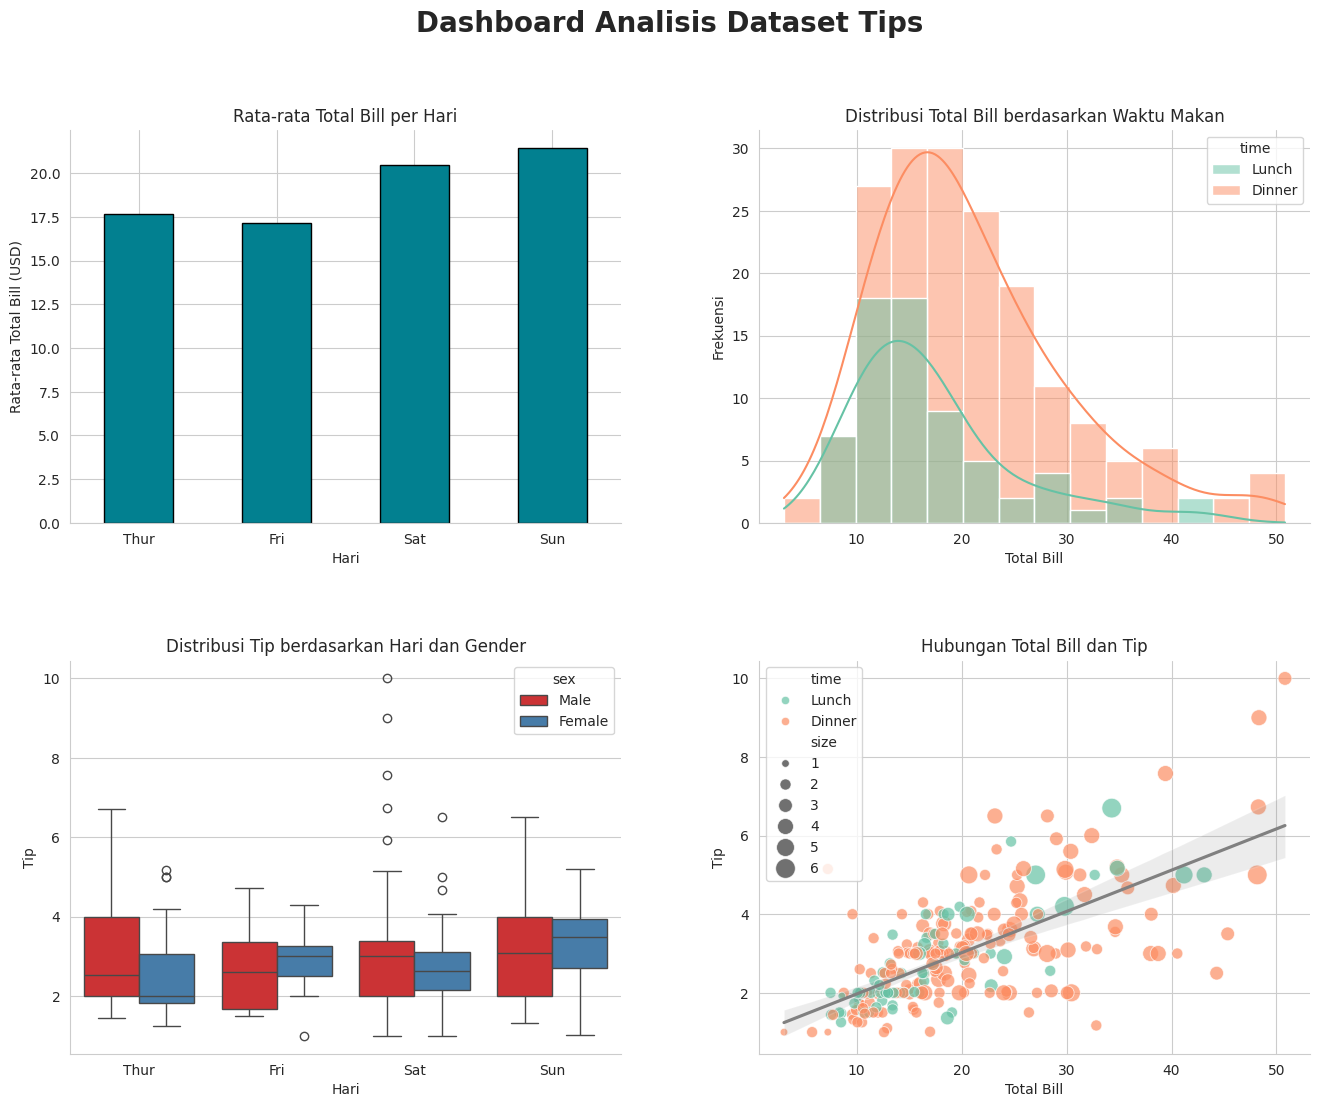

Dashboard berhasil disimpan sebagai dashboard_tips.png


In [6]:
# =========================================================
# DASHBOARD VISUALISASI STATIS DATASET TIPS
# =========================================================

fig = plt.figure(figsize=(16, 12))

fig.suptitle(
    'Dashboard Analisis Dataset Tips',
    fontsize=20,
    fontweight='bold',
    y=0.98
)

# Layout 2x2
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.35,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# =========================================================
# GRAFIK 1 - BAR CHART
# =========================================================

avg_bill = df.groupby('day')['total_bill'].mean()

avg_bill.plot(
    kind='bar',
    color='#028090',
    edgecolor='black',
    ax=ax1
)

ax1.set_title('Rata-rata Total Bill per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Rata-rata Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)

# =========================================================
# GRAFIK 2 - HISTOGRAM
# =========================================================

sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Total Bill berdasarkan Waktu Makan')
ax2.set_xlabel('Total Bill')
ax2.set_ylabel('Frekuensi')

# =========================================================
# GRAFIK 3 - BOXPLOT
# =========================================================

sns.boxplot(
    data=df,
    x='day',
    y='tip',
    hue='sex',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Distribusi Tip berdasarkan Hari dan Gender')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Tip')

# =========================================================
# GRAFIK 4 - SCATTER PLOT
# =========================================================

sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 200),
    alpha=0.7,
    palette='Set2',
    ax=ax4
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Hubungan Total Bill dan Tip')
ax4.set_xlabel('Total Bill')
ax4.set_ylabel('Tip')

# Hilangkan garis atas & kanan
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines[['top', 'right']].set_visible(False)

# Simpan dashboard
plt.savefig(
    'dashboard_tips.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Dashboard berhasil disimpan sebagai dashboard_tips.png")

### Analisis Grafik 1 — Rata-rata Total Bill per Hari

**What?**  
Hari Minggu (Sun) memiliki rata-rata total bill tertinggi sekitar 21 USD, sedangkan Jumat (Fri) memiliki rata-rata terendah sekitar 17 USD. Hal ini menunjukkan adanya perbedaan pola pengeluaran pelanggan berdasarkan hari.

**So what?**  
Perbedaan ini penting karena dapat membantu restoran memahami kapan pelanggan cenderung melakukan pengeluaran lebih besar. Hari dengan rata-rata bill tinggi berpotensi memberikan keuntungan lebih besar.

**Now what?**  
Restoran dapat mempertimbangkan strategi promosi khusus pada hari dengan rata-rata bill rendah seperti Jumat untuk meningkatkan transaksi pelanggan.

### Analisis Grafik 2 — Distribusi Total Bill

**What?**  
Sebagian besar transaksi berada pada rentang 10–20 USD. Selain itu, waktu makan malam (Dinner) mendominasi jumlah transaksi dibanding makan siang (Lunch).

**So what?**  
Hal ini menunjukkan bahwa restoran lebih ramai pada waktu makan malam dan pelanggan cenderung mengeluarkan biaya lebih besar saat dinner.

**Now what?**  
Manajemen restoran dapat menambah jumlah staf atau membuat paket menu dinner karena permintaan lebih tinggi pada waktu tersebut.

### Analisis Grafik 3 — Distribusi Tip berdasarkan Hari dan Gender

**What?**  
Distribusi tip pada hari Sabtu dan Minggu memiliki variasi lebih besar dibanding hari lainnya. Beberapa pelanggan memberikan tip yang sangat tinggi.

**So what?**  
Variasi tip yang besar menunjukkan perilaku pelanggan yang berbeda-beda pada akhir pekan, kemungkinan dipengaruhi jumlah tamu atau jenis layanan.

**Now what?**  
Restoran dapat melakukan analisis tambahan terkait kualitas pelayanan dan ukuran kelompok pelanggan terhadap besar tip yang diberikan.

### Analisis Grafik 4 — Hubungan Total Bill dan Tip

**What?**  
Terdapat hubungan positif antara total bill dan tip. Semakin besar total bill, maka tip yang diberikan pelanggan juga cenderung meningkat.

**So what?**  
Hubungan ini menunjukkan bahwa tip dipengaruhi oleh jumlah transaksi pelanggan. Garis regresi memperlihatkan tren kenaikan yang cukup jelas.

**Now what?**  
Restoran dapat mempelajari faktor lain seperti kualitas layanan atau ukuran kelompok pelanggan untuk memahami faktor yang memengaruhi tip lebih lanjut.